In [5]:
from PIL import Image
import numpy as np
import os
import glob
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score,classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns


train_dir = '/kaggle/input/animalsvsplants/train'
test_dir = '/kaggle/input/animalsvsplants/test'

train_image_paths = glob.glob(os.path.join(train_dir, '*/*.*'))
test_image_paths = glob.glob(os.path.join(test_dir, '*.*'))

def load_and_preprocess_images(image_paths, image_size, class_indices=None):
    images = []
    labels = []
    for image_path in image_paths:
        try:
            with Image.open(image_path) as img:
                img = img.convert('RGB')
                img = img.resize(image_size)
                img_array = np.array(img) / 255.0 
                images.append(img_array)
                if class_indices is not None:
                    class_name = os.path.basename(os.path.dirname(image_path))
                    if class_name in class_indices:
                        labels.append(class_indices[class_name])
                    else:
                        print(f"Advertencia: Clase no encontrada para la imagen {image_path}")

        except Exception as e:
            print(f"Error al procesar la imagen {image_path}: {e}")

    images = np.array(images)
    if class_indices is not None:
        labels = np.array(labels)
        return images, labels
    else:
        return images

In [29]:
train_class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
class_indices = {class_name: idx for idx, class_name in enumerate(train_class_names)}

num_classes = len(train_class_names)
print(f"Se han cargado {num_classes} clases de entrenamiento.")
print(f"Clases encontradas: {train_class_names}")

image_size = (10, 10) 
X, y = load_and_preprocess_images(train_image_paths, image_size, class_indices)
for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    if len(images) == 0:
        print(f"Advertencia: La clase '{class_name}' no tiene imágenes.")
    else:
        print(f"La clase '{class_name}' tiene {len(images)} imágenes.")

Se han cargado 16 clases de entrenamiento.
Clases encontradas: ['Scentless Mayweed', 'horse', 'Common wheat', 'Charlock', 'Black-grass', 'dog', 'Sugar beet', 'Loose Silky-bent', 'Maize', 'cow', 'Cleavers', 'Common Chickweed', 'Fat Hen', 'Small-flowered Cranesbill', 'cat', 'Shepherds Purse']
La clase 'Scentless Mayweed' tiene 516 imágenes.
La clase 'horse' tiene 164 imágenes.
La clase 'Common wheat' tiene 221 imágenes.
La clase 'Charlock' tiene 390 imágenes.
La clase 'Black-grass' tiene 263 imágenes.
La clase 'dog' tiene 164 imágenes.
La clase 'Sugar beet' tiene 385 imágenes.
La clase 'Loose Silky-bent' tiene 654 imágenes.
La clase 'Maize' tiene 221 imágenes.
La clase 'cow' tiene 164 imágenes.
La clase 'Cleavers' tiene 287 imágenes.
La clase 'Common Chickweed' tiene 611 imágenes.
La clase 'Fat Hen' tiene 475 imágenes.
La clase 'Small-flowered Cranesbill' tiene 496 imágenes.
La clase 'cat' tiene 164 imágenes.
La clase 'Shepherds Purse' tiene 231 imágenes.


VERIFICAMOS LA CARGA DE LAS IMAGENES

In [38]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplanar las imágenes 
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# Escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)

pca = PCA(n_components=85)  # Ajusta el número de componentes según sea necesario
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)





In [39]:
model = LogisticRegression(
    multi_class='ovr',
    solver='saga',
    penalty='l2',
    C=1.0,
    max_iter=1200,
    n_jobs=-1,
    random_state=42
)
model.fit(X_train_pca, y_train)

# Evaluar en el conjunto de validación
y_val_pred = model.predict(X_val_pca)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy en el conjunto de validación: {accuracy:.4f}")

print("Reporte de clasificación:")
print(classification_report(y_val, y_val_pred, target_names=train_class_names))


Accuracy en el conjunto de validación: 0.4048
Reporte de clasificación:
                           precision    recall  f1-score   support

        Scentless Mayweed       0.38      0.41      0.39       103
                    horse       0.46      0.36      0.41        33
             Common wheat       0.00      0.00      0.00        44
                 Charlock       0.50      0.65      0.56        78
              Black-grass       0.36      0.17      0.23        53
                      dog       0.29      0.15      0.20        33
               Sugar beet       0.30      0.14      0.19        77
         Loose Silky-bent       0.36      0.82      0.50       131
                    Maize       0.31      0.09      0.14        44
                      cow       0.56      0.55      0.55        33
                 Cleavers       0.56      0.43      0.49        58
         Common Chickweed       0.41      0.57      0.48       122
                  Fat Hen       0.18      0.09      0.12

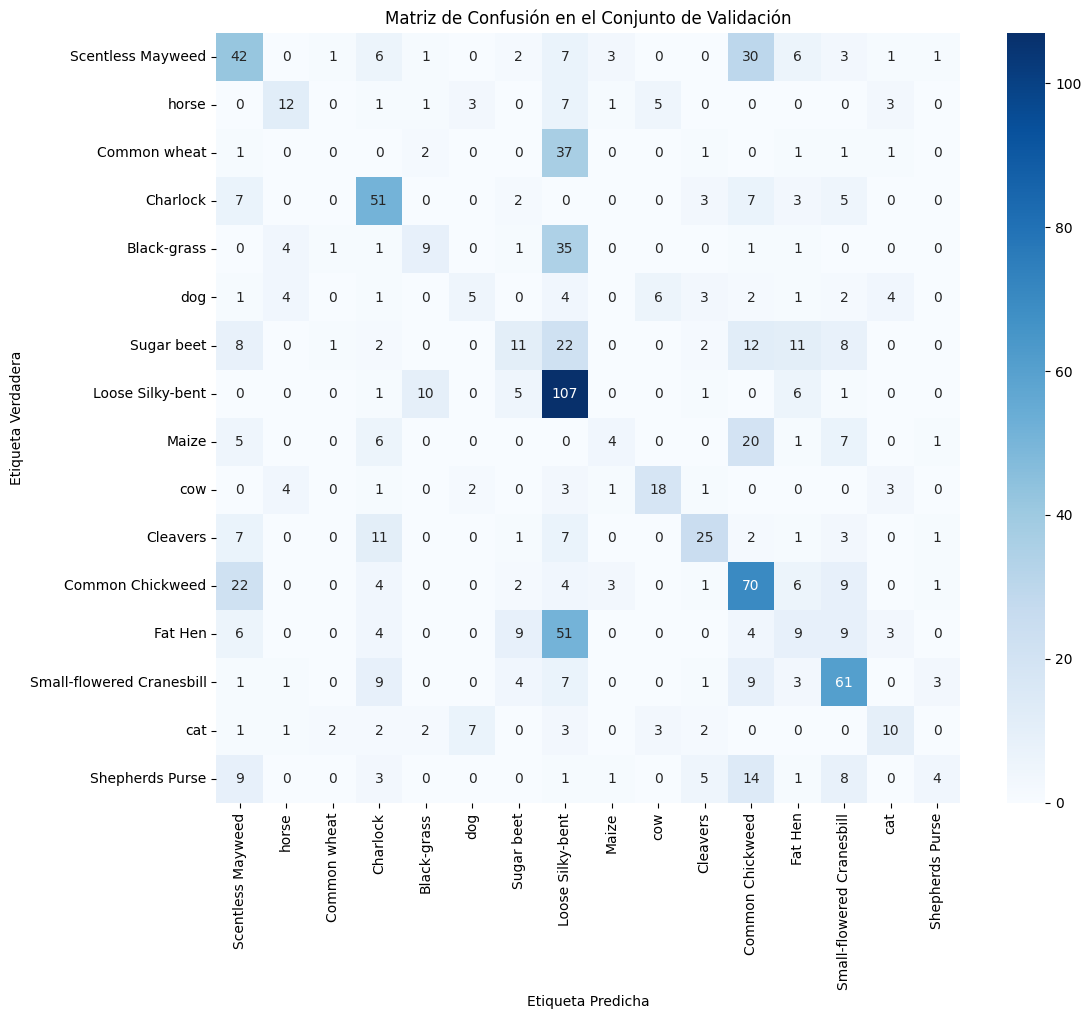

In [40]:


cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_class_names, yticklabels=train_class_names, cmap='Blues')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.title('Matriz de Confusión en el Conjunto de Validación')
plt.show()

In [42]:

X_test = load_and_preprocess_images(test_image_paths, image_size)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
X_test_scaled = scaler.transform(X_test_flat)
X_test_pca = pca.transform(X_test_scaled)

y_test_pred = model.predict(X_test_pca)

test_filenames = [os.path.basename(path) for path in test_image_paths]
submission_df = pd.DataFrame({
    'filename': test_filenames,
    'label': [train_class_names[label] for label in y_test_pred]
})

submission_df.to_csv('submission.csv', index=False)
print("Archivo de envío generado: submission.csv")

Archivo de envío generado: submission.csv


**Conjunto de test**